<a href="https://colab.research.google.com/github/Aswini-Dileep/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Prediction Using Machine Learning**

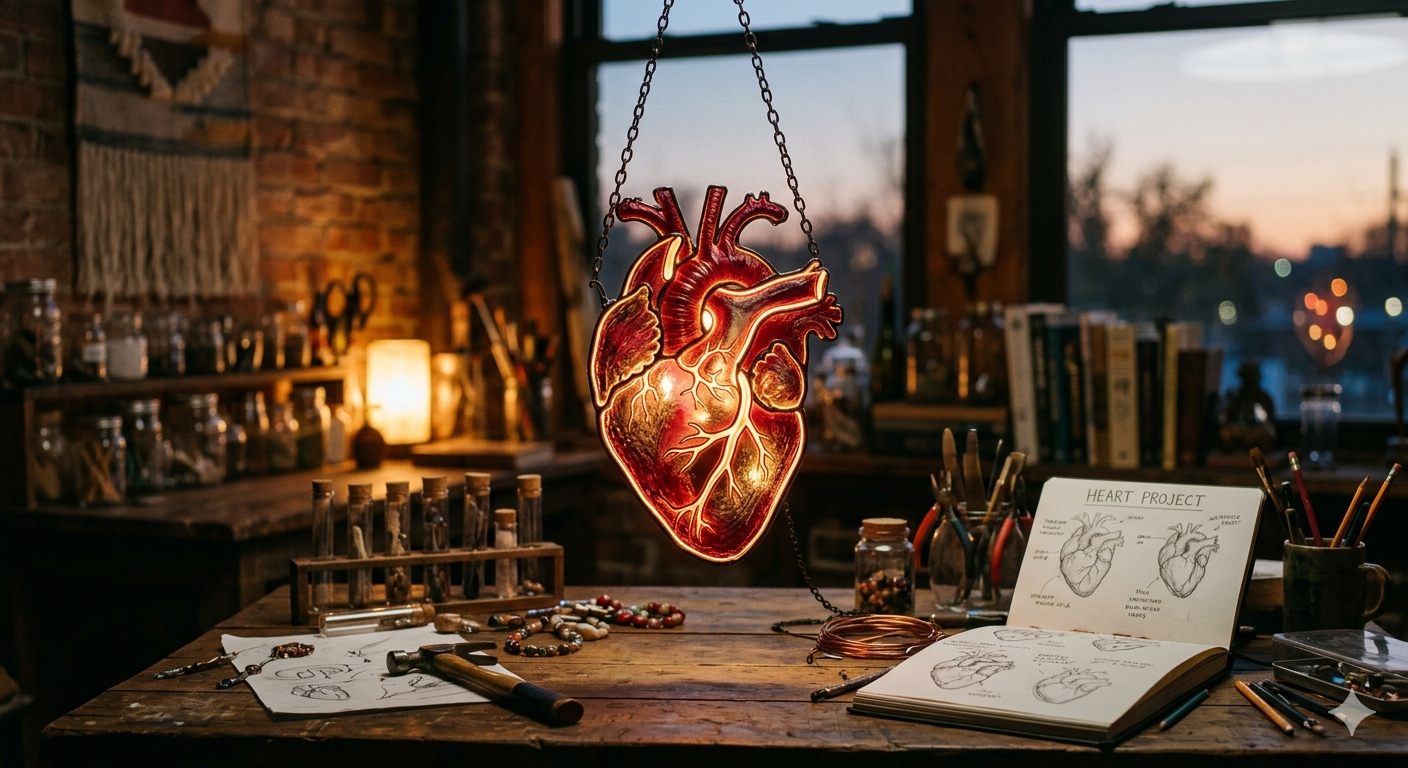

**Objective**

The objective of this project is to develop a machine learning model that predicts the presence of heart disease based on clinical and physiological patient data. Early detection of heart disease is critical for preventing severe health complications and improving patient outcomes.

Using the Kaggle Playground Series S6E2 dataset, this project analyzes various health indicators such as age, cholesterol levels, blood pressure, ECG results, and exercise-related metrics to identify patterns associated with heart disease.

The goal is to perform exploratory data analysis, build predictive models, and evaluate their performance in accurately classifying patients as having heart disease or not.

**Project Goals**

* Understand the dataset and feature relationships

* Perform exploratory data analysis (EDA)

* Visualize patterns in patient health metrics

* Build machine learning models to predict heart disease

* Evaluate model performance using classification metrics

**Expected Outcome**

The final outcome of this project is a predictive machine learning model capable of identifying patients at risk of heart disease, which can assist healthcare professionals in early diagnosis and preventive treatment.

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score


Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_df = pd.read_csv("/content/drive/MyDrive/Private Projects/Heart Disease Prediction/train.csv")


In [4]:
test_df = pd.read_csv("/content/drive/MyDrive/Private Projects/Heart Disease Prediction/test.csv")

In [5]:
print(f'Dataset Shape: {train_df.shape}')
print('\n First 5 Rows:')
train_df.head()

Dataset Shape: (630000, 15)

 First 5 Rows:


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


The dataset contains 630,000 records and 15 columns, including 14 predictor variables and 1 target variable. The first few rows of the dataset provide an overview of the available features and their values.

In [6]:
print(test_df.shape)
test_df.head()

(270000, 14)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [7]:
# Detailed information of dataset column name and datatypes
print(f'Detailed information of dataset column name and datatypes:')
print(train_df.info())


Detailed information of dataset column name and datatypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  

Most features are numerical, while the target variable Heart Disease is stored as a categorical object.

In [8]:
# Basic statistics for numeric columns
print(f'Statistical Summary:')
train_df.describe()

Statistical Summary:


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


**Statistical Summary Interpretation**

The statistical summary provides an overview of the distribution and central tendency of the numerical features in the dataset. It includes key statistical measures such as the mean, standard deviation, minimum and maximum values, and quartiles for each feature. These statistics help us understand the overall characteristics of the dataset and identify potential patterns or anomalies.

The dataset contains 630,000 patient records, making it a relatively large dataset suitable for machine learning analysis. The Age feature ranges from 29 to 77 years, with an average age of approximately 54 years, indicating that the dataset primarily represents middle-aged and older adults who are more likely to undergo cardiovascular evaluation.

The Sex feature is encoded as a binary variable where 0 represents female and 1 represents male. The mean value of approximately 0.71 suggests that the dataset contains a higher proportion of male patients compared to female patients.

The Chest Pain Type variable ranges from 1 to 4, representing different categories of chest pain experienced by patients. These categories correspond to various clinical conditions that may be associated with heart disease symptoms.

The Resting Blood Pressure (BP) has an average value of around 130 mmHg, with values ranging from 94 to 200 mmHg. This indicates that while many patients fall within the normal or slightly elevated blood pressure range, some individuals exhibit significantly higher values that may indicate hypertension.

The Cholesterol levels show a mean value of approximately 245 mg/dL, with values ranging from 126 to 564 mg/dL. Higher cholesterol levels are commonly associated with increased risk of cardiovascular disease, making this an important predictor in the dataset.

The Maximum Heart Rate (Max HR) achieved during exercise ranges from 71 to 202 beats per minute, with an average of approximately 153 bpm. This feature reflects the cardiovascular response of patients during physical exertion.

The ST Depression feature measures the depression in the ST segment of the ECG induced by exercise relative to rest. The values range from 0.0 to 6.2, with an average of 0.71, which may indicate varying levels of cardiac stress among patients.

The Number of Vessels Fluoroscopy variable ranges from 0 to 3, representing the number of major blood vessels detected through fluoroscopy imaging. Higher values may indicate more significant coronary artery blockage.

The Thallium Stress Test results range from 3 to 7, representing different outcomes of the thallium imaging test used to evaluate blood flow to the heart muscle.

Overall, the statistical summary indicates that the dataset contains a mix of continuous numerical variables and encoded categorical variables. Understanding these distributions helps guide the next steps of exploratory data analysis and feature engineering for building predictive machine learning models.



In [9]:
# Check Missing Values
train_df.isnull().sum()

,0
id,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0


The dataset does not contain any missing values, which simplifies the preprocessing stage.

## **Exploratory Data Analysis (EDA)**

In [10]:
# Unique Values in Each Column
train_df.nunique()

,0
id,630000
Age,42
Sex,2
Chest pain type,4
BP,66
Cholesterol,150
FBS over 120,2
EKG results,3
Max HR,93
Exercise angina,2


**Categorical Variable Explanation**

Several features contain a small number of unique values, indicating that they represent categorical variables encoded numerically. These variables represent different medical conditions or patient characteristics rather than continuous numerical measurements.

Understanding these categorical variables is important for interpreting the dataset and selecting appropriate preprocessing techniques for machine learning models.



* Sex

Number of unique values: 2

Value	Meaning:

0 - Female

1 - Male

This feature represents the gender of the patient. Sex is an important factor in cardiovascular risk analysis, as heart disease prevalence often differs between males and females.



* Chest Pain Type

Number of unique values: 4

Value	Meaning:

1	- Typical Angina

2	- Atypical Angina

3	- Non-Anginal Pain

4	- Asymptomatic

This variable describes the type of chest pain experienced by the patient.
Angina is chest pain or discomfort you feel when there is not enough blood flow to your heart muscle.

Typical Angina - Chest pain strongly associated with reduced blood flow to the heart.

Atypical Angina - Chest discomfort that resembles angina but does not follow classic patterns.

Non-Anginal Pain - Chest pain not related to heart disease.

Asymptomatic - No chest pain symptoms.

Chest pain type is considered one of the most important indicators of heart disease.



* Fasting Blood Sugar (FBS over 120)

Number of unique values: 2

Value	Meaning:

0	- Fasting blood sugar ≤ 120 mg/dl

1	- Fasting blood sugar > 120 mg/dl

This feature indicates whether a patient's fasting blood sugar level exceeds 120 mg/dl. Elevated fasting blood sugar levels can be associated with diabetes, which is a known risk factor for cardiovascular disease.


* EKG Results

Number of unique values: 3

Value	Meaning:

0 -	Normal ECG

1 -	ST-T wave abnormality

2 -	Left ventricular hypertrophy

This variable represents the results of the resting electrocardiogram (ECG) test, which measures the electrical activity of the heart.

Abnormal ECG readings may indicate structural or functional heart problems.


* Exercise Angina

Number of unique values: 2

Value	Meaning:

0 -	No exercise-induced angina

1	- Exercise-induced angina present

This feature indicates whether the patient experiences chest pain during physical activity. Exercise-induced angina is often associated with reduced blood supply to the heart muscle.

* Slope of ST Segment

Number of unique values: 3

Value	Meaning:

1 -	Upsloping

2	- Flat

3 -	Downsloping

This variable describes the slope of the ST segment in the ECG during exercise testing.

The slope of the ST segment provides important information about heart stress and potential ischemia.


* Number of Vessels (Fluoroscopy)

Number of unique values: 4

Value	Meaning:

0	- No vessels affected

1	- One major vessel

2	- Two major vessels

3	- Three major vessels

This feature indicates the number of major blood vessels detected through fluoroscopy imaging. Higher values may indicate more severe coronary artery blockage.


* Thallium Test Result

Number of unique values: 3

Value	Meaning:

3 -	Normal

6	- Fixed defect

7	- Reversible defect

The Thallium stress test evaluates blood flow to the heart muscle.

Normal - Healthy blood flow

Fixed defect - Permanent damage in heart muscle

Reversible defect - Temporary reduction in blood flow during stress

This test is commonly used in diagnosing coronary artery disease.


* Heart Disease (Target Variable)

Number of unique values: 2

Value	Meaning:

Absence -	No heart disease

Presence -	Heart disease detected

This is the target variable for the machine learning model. The goal of the project is to predict whether a patient has heart disease based on the available medical features.

Summary

The dataset contains several categorical variables encoded as numerical values, including patient characteristics, diagnostic test results, and exercise-related measurements. Proper understanding of these variables is essential for accurate data analysis and effective machine learning model development.

In [11]:
# Target Variable Distribution
train_df["Heart Disease"].value_counts(normalize= True)*100

,proportion
Heart Disease,
Absence,55.166032
Presence,44.833968


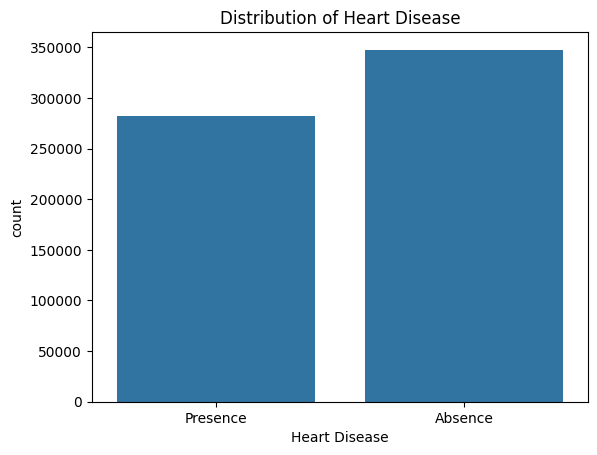

In [12]:
sns.countplot(x="Heart Disease", data=train_df)
plt.title("Distribution of Heart Disease")
plt.show()

The dataset shows a slightly higher proportion of patients without heart disease (55.17%) compared to those with heart disease (44.83%). The dataset is relatively balanced, which is beneficial for training machine learning models.

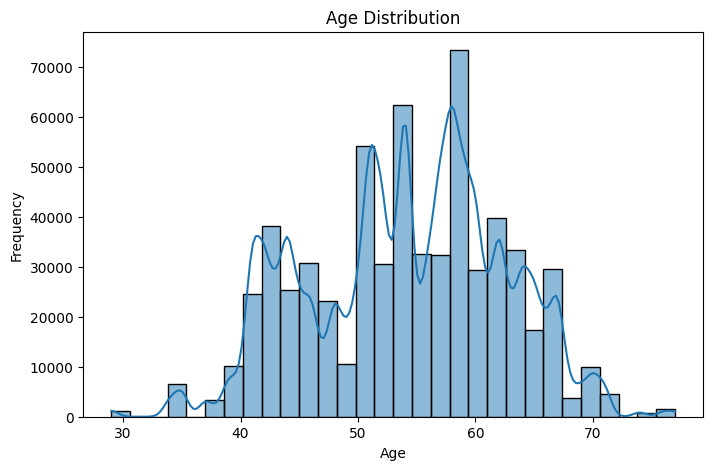

In [13]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(train_df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution plot shows that most patients in the dataset fall within the 40–65 age range, with the peak concentration around the mid-50s. This indicates that the dataset primarily contains middle-aged and older individuals, which aligns with medical knowledge since the risk of cardiovascular diseases tends to increase with age.

There are relatively fewer patients in the younger age group (below 40) and the elderly population above 70. The distribution appears slightly right-skewed, suggesting that the majority of patients are concentrated in the middle age groups.




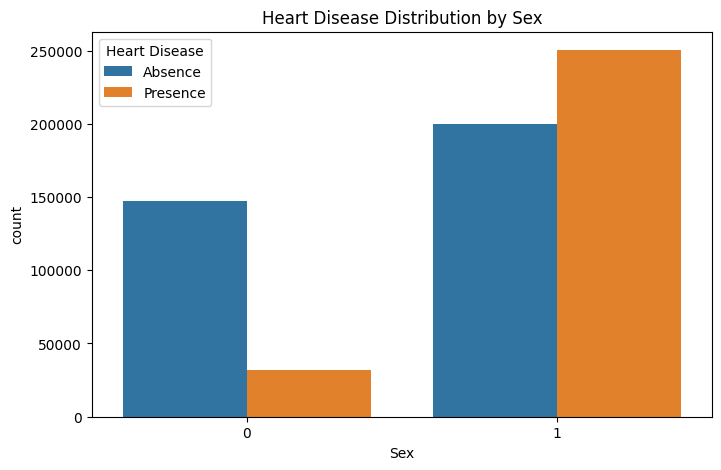

In [14]:
# Heart Disease Distribution by Sex
plt.figure(figsize=(8,5))
sns.countplot(x="Sex", hue="Heart Disease", data=train_df)
plt.title("Heart Disease Distribution by Sex")
plt.show()

This visualization compares the presence and absence of heart disease across male and female patients.

The plot shows that male patients (Sex = 1) have a significantly higher number of heart disease cases compared to female patients (Sex = 0). While many male patients still fall under the absence category, the number of heart disease cases among males is noticeably higher than among females.

This observation aligns with established medical findings that men generally have a higher risk of developing heart disease compared to women, particularly during middle age.

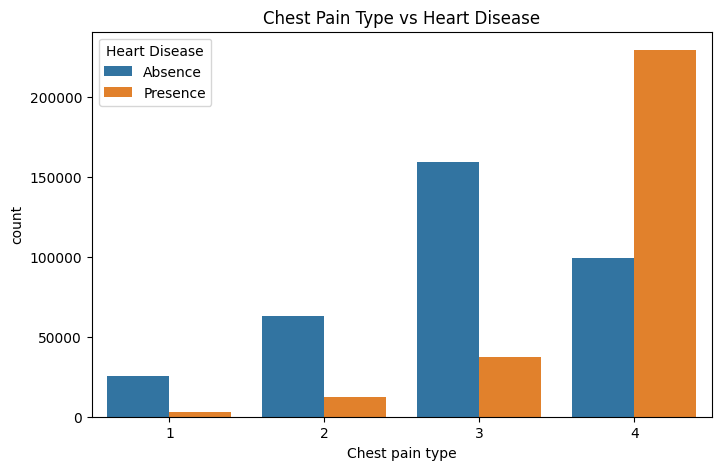

In [15]:
# Chest Pain Type vs Heart Disease
plt.figure(figsize=(8,5))
sns.countplot(x="Chest pain type", hue="Heart Disease", data=train_df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

This plot illustrates the relationship between different types of chest pain and the presence of heart disease.

The results indicate that Chest Pain Type 4 (Asymptomatic) has the highest number of patients with heart disease. This suggests that many individuals diagnosed with heart disease may not always exhibit typical chest pain symptoms.

In contrast, Chest Pain Types 1 and 2 show a much lower number of heart disease cases. Chest Pain Type 3 has a moderate number of cases but still shows more absence than presence of heart disease.

These findings highlight that chest pain characteristics are an important clinical indicator for detecting potential cardiovascular problems.

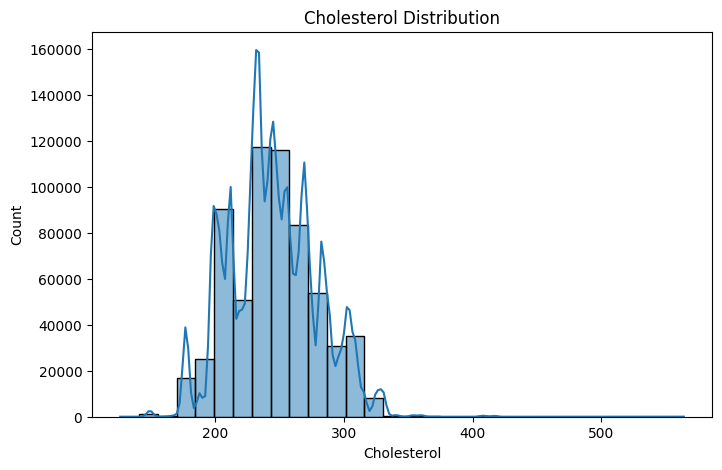

In [16]:
# Cholesterol Distribution
plt.figure(figsize=(8,5))
sns.histplot(train_df["Cholesterol"], bins=30, kde=True)
plt.title("Cholesterol Distribution")
plt.show()

The cholesterol distribution plot shows that most patients have cholesterol levels ranging between 200 and 300 mg/dL, with the peak concentration around 240–260 mg/dL.

The distribution appears slightly right-skewed, indicating that while most patients have cholesterol levels within a moderate range, some individuals exhibit very high cholesterol values exceeding 400 mg/dL.

Elevated cholesterol is a well-known risk factor for cardiovascular diseases, and this feature may play an important role in predicting heart disease in the dataset.

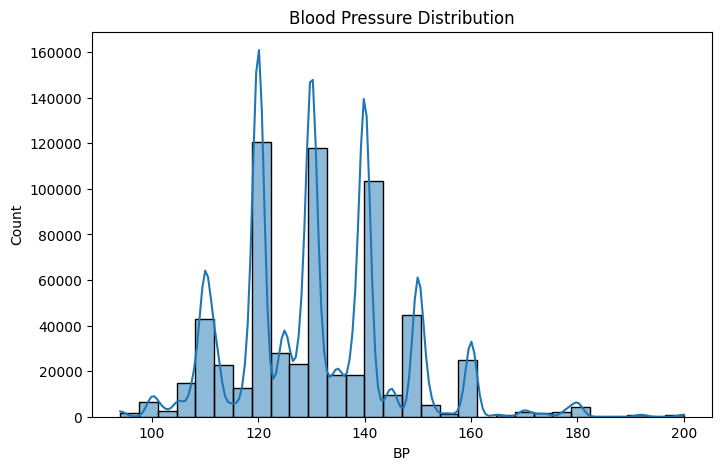

In [17]:
# Blood Pressure Distribution
plt.figure(figsize=(8,5))
sns.histplot(train_df["BP"], bins=30, kde=True)
plt.title("Blood Pressure Distribution")
plt.show()


The blood pressure distribution shows that most patients have resting blood pressure values between 110 and 150 mmHg, with the highest concentration around 120–140 mmHg.

This range includes both normal and mildly elevated blood pressure levels. A smaller number of patients exhibit very high blood pressure values above 160 mmHg, which may indicate hypertension.

Since high blood pressure is one of the major contributors to cardiovascular disease, this feature is expected to have predictive importance in the heart disease classification model.

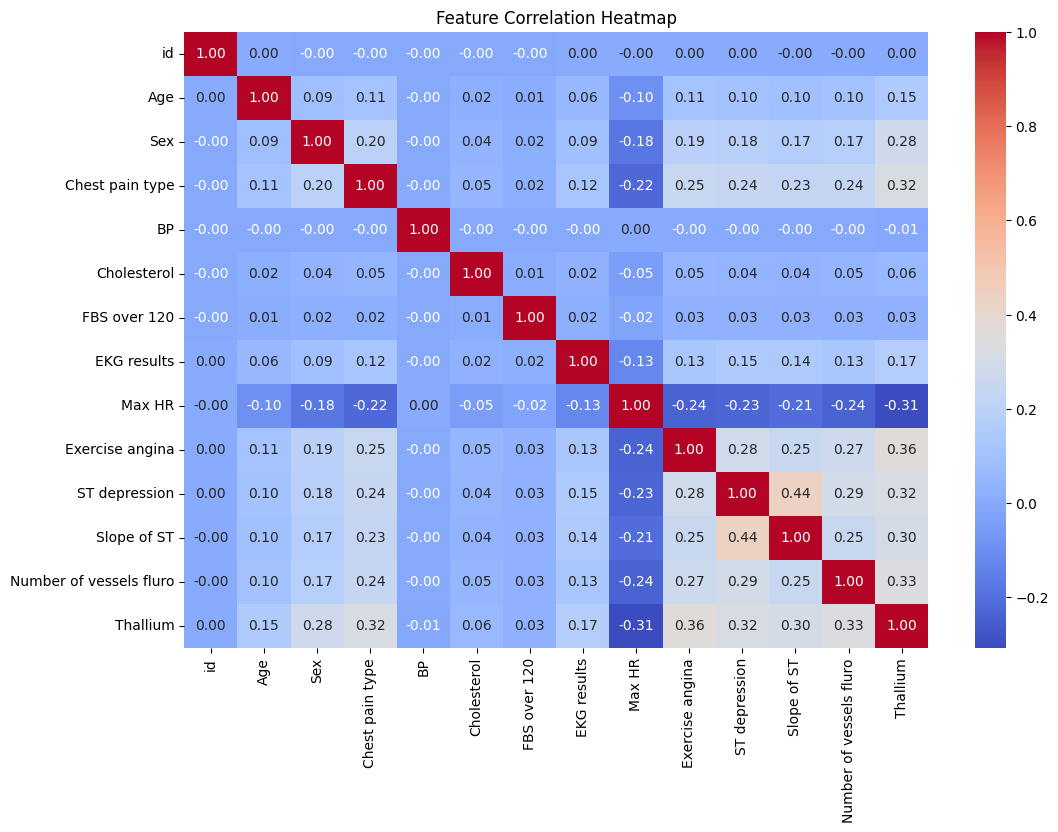

In [18]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
corr = train_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**Feature Correlation Heatmap Interpretation**

The correlation heatmap illustrates the pairwise correlation between numerical features in the dataset. Correlation values range from -1 to +1, where:

+1 indicates a strong positive correlation

-1 indicates a strong negative correlation

0 indicates little to no linear relationship between variables

The heatmap helps identify relationships between features, which can provide insights into how different clinical variables interact with each other.

Key Observations

Age Relationships

Age shows a weak positive correlation with several features such as chest pain type, exercise angina, and ST depression. This suggests that as age increases, the likelihood of certain heart-related symptoms may also slightly increase.

Sex and Heart-Related Features

Sex has moderate correlations with several variables including chest pain type, exercise angina, and thallium test results. This suggests that gender may influence the occurrence of certain cardiovascular conditions.

Chest Pain Type

Chest pain type shows moderate positive correlations with features such as ST depression, slope of ST segment, and number of affected vessels. This indicates that patients experiencing certain types of chest pain may also show other signs of cardiovascular abnormalities.

Maximum Heart Rate

Maximum heart rate (Max HR) shows negative correlations with several features, including exercise angina, ST depression, slope of ST, and thallium test results. This suggests that patients with higher maximum heart rates during exercise may have fewer indicators of severe cardiovascular stress.

Exercise Angina and ST Depression

Exercise angina shows a moderate positive correlation with ST depression and slope of ST segment. This relationship is clinically meaningful because exercise-induced chest pain often occurs alongside abnormal ECG changes during stress testing.

Number of Vessels and Thallium Test

The number of vessels detected through fluoroscopy shows a moderate correlation with thallium test results. This suggests that abnormal thallium imaging results may be associated with a higher number of affected coronary vessels.

Overall Interpretation

Most features in the dataset exhibit weak to moderate correlations, indicating that they provide distinct and complementary information for predicting heart disease. The absence of extremely high correlations between most variables suggests that multicollinearity is not a major concern, which is beneficial for building machine learning models.

The heatmap also highlights several clinically meaningful relationships between cardiovascular indicators such as chest pain type, exercise angina, ST depression, and thallium test results. These variables are likely to play an important role in predicting the presence of heart disease in subsequent modeling steps.

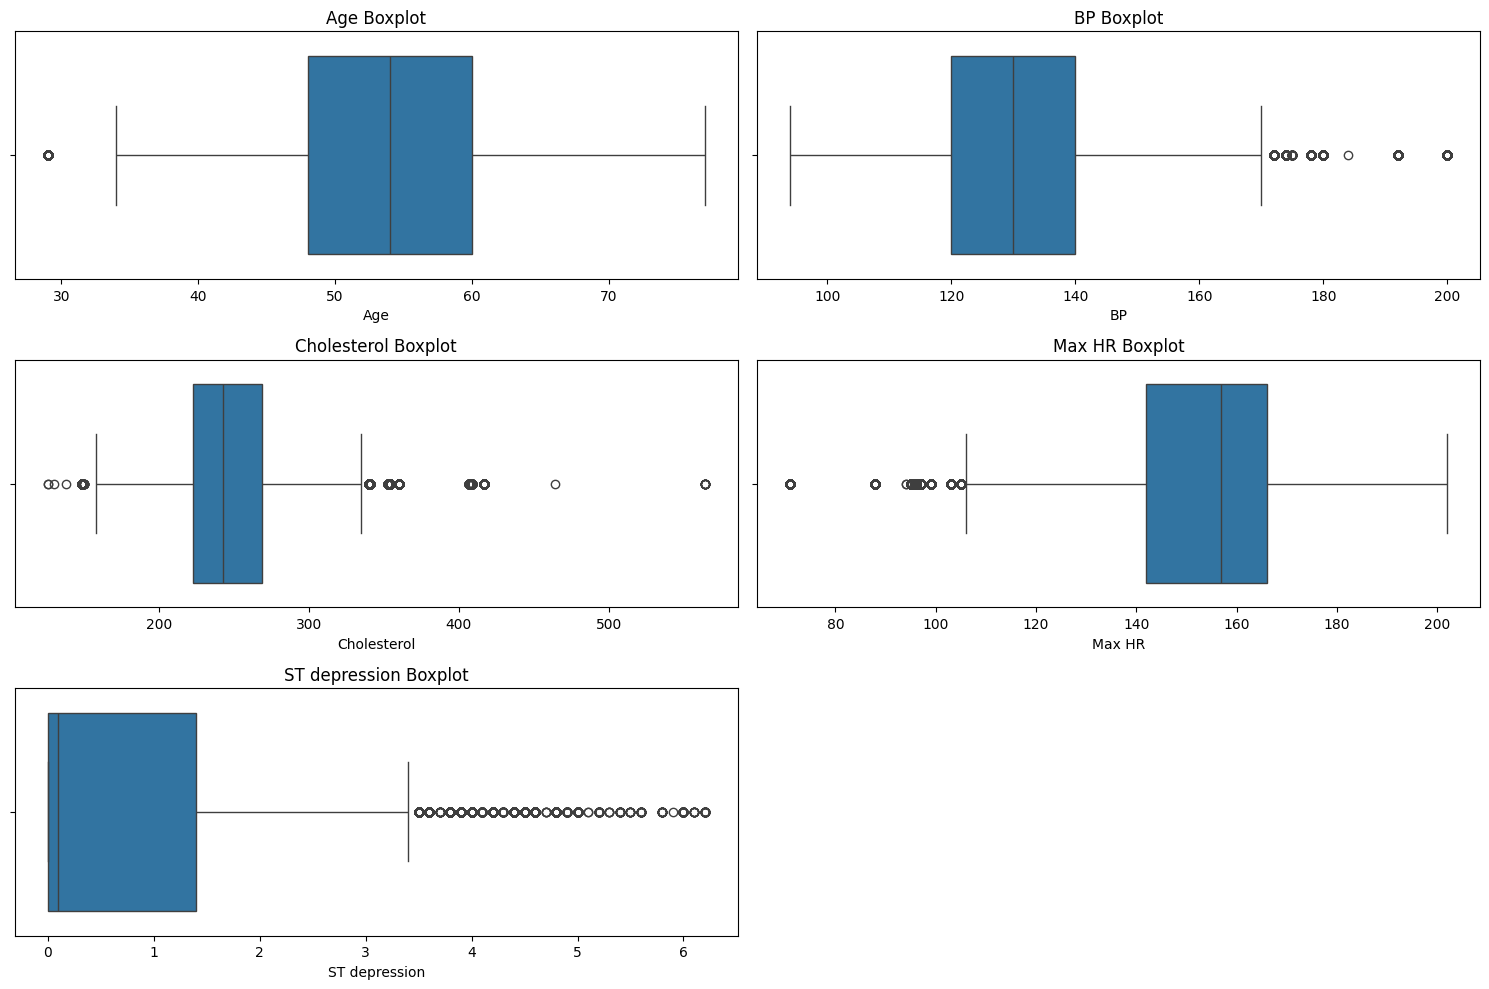

In [19]:
# Outlier Detection
numerical_cols = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=train_df[col])
    plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

**Outlier Analysis Interpretation**

Boxplots were used to identify potential outliers in the numerical features, including Age, Blood Pressure (BP), Cholesterol, Maximum Heart Rate (Max HR), and ST Depression.

Key Observations

Age

The Age feature shows a relatively stable distribution with very few outliers. Most patients fall within a reasonable age range (40-65 years), indicating no significant anomalies.

Blood Pressure (BP)

Blood pressure values are mostly concentrated between 110 and 150 mmHg, but there are several high-value outliers above 170 mmHg. These may represent patients with severe hypertension.

Cholesterol

Cholesterol exhibits notable outliers, especially on the higher end, with some values exceeding 400-500 mg/dL. These extreme values could indicate patients with very high cardiovascular risk.

Maximum Heart Rate (Max HR)

Max HR shows a few low-value outliers, with some patients having unusually low maximum heart rates. This could be due to underlying cardiac conditions or limited physical capacity.

ST Depression

ST depression displays the most significant number of outliers, particularly on the higher end (above 3.0). This suggests substantial variability in ECG responses during exercise, which may be clinically important.

Overall Interpretation

The dataset contains several outliers, particularly in Cholesterol, Blood Pressure, and ST Depression. However, since this is a medical dataset, these extreme values are likely to represent real patient conditions rather than data errors.Since the dataset is large and the outliers may carry important clinical information, no aggressive outlier removal is performed.

**Feature Importance Analysis**

Which features actually matter for predicting heart disease?

Feature importance analysis was performed using a Random Forest model to identify the most influential variables in predicting heart disease.

In [20]:
# Step 1: Prepare Data
# Convert target
train_df["Heart Disease"] = train_df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

# Drop id
train_df = train_df.drop("id", axis=1)

# Split features and target
X = train_df.drop("Heart Disease", axis=1)
y = train_df["Heart Disease"]

In [21]:
# Step 2: Train a Simple Model

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [22]:
# Step 3: Get Feature Importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
12,Thallium,0.183319
2,Chest pain type,0.138632
7,Max HR,0.135659
4,Cholesterol,0.087085
11,Number of vessels fluro,0.078797
0,Age,0.076309
9,ST depression,0.073200
8,Exercise angina,0.067905
3,BP,0.060924
10,Slope of ST,0.055831


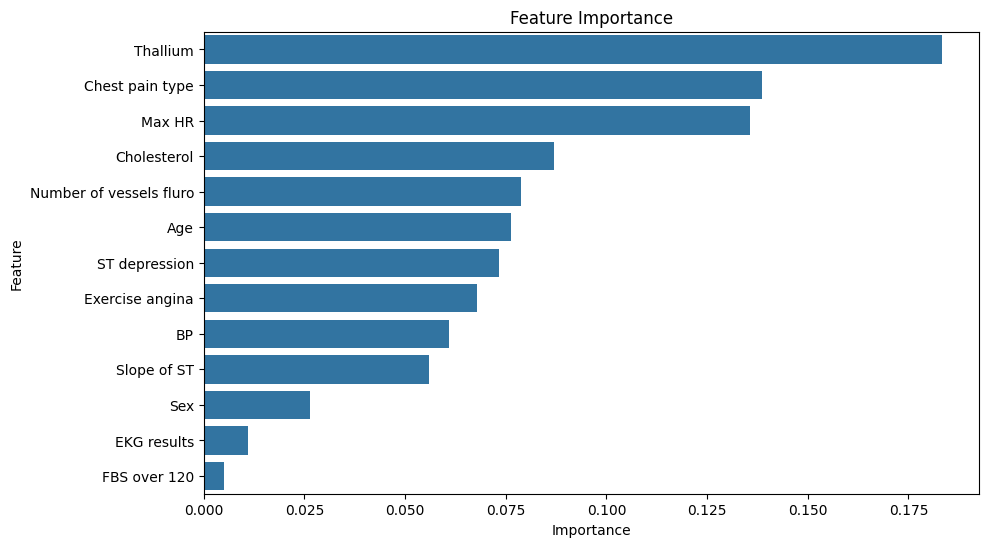

In [23]:
# Step 4: Visualize Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance")
plt.show()

**Feature Importance Interpretation**

Feature importance analysis was conducted using a Random Forest classifier to identify the most influential variables in predicting heart disease.

The results show that Thallium test results are the most important feature, indicating that abnormalities in blood flow to the heart play a critical role in detecting heart disease. Chest pain type and maximum heart rate (Max HR) are also highly influential, highlighting the importance of exercise-related symptoms and cardiovascular response in diagnosis.

Moderately important features include cholesterol levels, number of vessels detected through fluoroscopy, age, and ST depression. These features are clinically relevant, as they reflect structural and functional aspects of the heart and are commonly associated with cardiovascular risk.

Features such as exercise-induced angina and blood pressure also contribute to the model, but with slightly lower importance. On the other hand, variables like sex, EKG results, and fasting blood sugar (FBS over 120) show relatively low importance, suggesting that they have limited impact on the model's predictive performance in this dataset.

Overall, the model relies more on diagnostic test results and exercise-related features rather than basic demographic variables. This indicates that physiological and clinical measurements are stronger predictors of heart disease compared to general patient characteristics.

**Model Building**

In [24]:
#Step 1: Train-Test Split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

**Model 1 — Logistic Regression**

In [26]:
# Model 1 — Logistic Regression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

Logistic Regression

* Fast

* Simple baseline

* Works well on large data

but sensitive to outliers

In [27]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_val, y_pred_lr))
print("Precision:", precision_score(y_val, y_pred_lr))
print("Recall:", recall_score(y_val, y_pred_lr))
print("F1 Score:", f1_score(y_val, y_pred_lr))
print()

Logistic Regression
Accuracy: 0.8821111111111111
Precision: 0.877894507252172
Recall: 0.855836699978737
F1 Score: 0.8667252857681196



In [28]:
confusion_matrix(y_val, y_pred_lr)

array([[62846,  6718],
       [ 8136, 48300]])

**Model 2 — Random Forest**

In [29]:
# Model 2 — Random Forest


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

Random Forest

* Handles nonlinear data
* Works well with mixed features
* Robust to outliers [Extreme values (very high or very low values) do not significantly affect the model’s performance.]

In [30]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Precision:", precision_score(y_val, y_pred_rf))
print("Recall:", recall_score(y_val, y_pred_rf))
print("F1 Score:", f1_score(y_val, y_pred_rf))
print()

Random Forest
Accuracy: 0.880484126984127
Precision: 0.8718746067981235
Recall: 0.8594691331774045
F1 Score: 0.865627425960792



In [31]:
# Confusion Matrix

confusion_matrix(y_val, y_pred_rf)

array([[62436,  7128],
       [ 7931, 48505]])

Interpretation

TN = 62,436 → correctly predicted no disease

TP = 48,505 → correctly predicted disease

FP = 7,128 → predicted disease but actually no disease

FN = 7,931 → missed disease ❗

Insight:

Random Forest is doing well, but it is missing 7,931 patients with heart disease, which is a concern in medical applications.

**Model 3 — XGBoost**

In [32]:
# Model 3 — XGBoost

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)

XGBoost

* Designed for large datasets
* Very fast and efficient
* Handles:

    * Nonlinearity
    * Feature interactions
    * Robust to outliers


In [33]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall:", recall_score(y_val, y_pred_xgb))
print("F1 Score:", f1_score(y_val, y_pred_xgb))

XGBoost
Accuracy: 0.8869920634920635
Precision: 0.8796401259559155
Recall: 0.8662201431710256
F1 Score: 0.8728785565703369


In [34]:
cm=confusion_matrix(y_val, y_pred_xgb)
cm

array([[62875,  6689],
       [ 7550, 48886]])

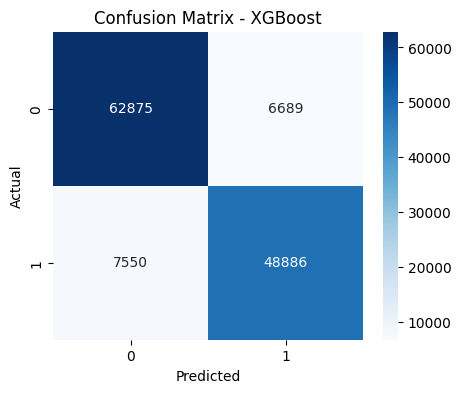

In [35]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

Interpretation

TN = 62,875 → highest correct negatives

TP = 48,886 → highest correct positives

FP = 6,689 → fewer false alarms

FN = 7,550 → lowest missed cases ❗

Insight:-

XGBoost performs the best by:

Reducing false negatives

Increasing true positives

Maintaining balanced performance

**Model 4 — Decision Tree**

In [36]:
# Model 4 — Decision Tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)

Decision Tree → fast, but usually less accurate than ensembles

In [37]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_val, y_pred_dt))
print("Precision:", precision_score(y_val, y_pred_dt))
print("Recall:", recall_score(y_val, y_pred_dt))
print("F1 Score:", f1_score(y_val, y_pred_dt))

Decision Tree
Accuracy: 0.824595238095238
Precision: 0.8018355398491481
Recall: 0.8081012119923453
F1 Score: 0.8049561833152419


In [38]:
confusion_matrix(y_val, y_pred_dt)

array([[58293, 11271],
       [10830, 45606]])

In medical problems, **False Negatives (FN)** are the most critical metric, because missing a patient with heart disease can lead to serious consequences.

Insight:

Very high false negatives (10,830) ❗❗

Poor performance overall

This is why Decision Tree performed worst.

**Model 5 - k-Nearest Neighbors (kNN)**

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_val_scaled)

k-Nearest Neighbors (kNN) Problem:

kNN compares each test point with ALL training points.
(dataset = 630,000 rows)

That means:

* Extremely slow predictions

* High memory usage

Conclusion:

kNN is not practical for large datasets and sensitive to outliers

**Model 6 - Support Vector Machine (SVM)**

from sklearn.svm import SVC

svm = SVC(kernel='linear')  # faster than rbf

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_val_scaled)

Support Vector Machine (SVM)
Problem:
* Training complexity grows quadratically or worse.
* Very slow for large datasets

With 630k rows:

Training becomes very slow or infeasible.

Conclusion:

SVM is not practical for large datasets and sensitive to outliers

**Model Evaluation**
* Accuracy → overall correctness
* Precision → how many predicted positives are correct
* Recall → how many actual positives are detected
* F1-score → balance between precision & recall

**Accuracy** measures the overall correctness of the model, while **precision** indicates how many of the predicted positive cases are actually correct. **Recall** measures the model's ability to correctly identify patients with heart disease, which is especially important in medical applications where missing a positive case can have serious consequences.

The **F1-score** provides a balance between precision and recall, offering a more comprehensive evaluation of model performance.

By using multiple evaluation metrics, we ensure that the selected model performs well not only in general accuracy but also in identifying true positive cases effectively.

In [39]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost","Decision Tree"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_lr),
        accuracy_score(y_val, y_pred_rf),
        accuracy_score(y_val, y_pred_xgb),
        accuracy_score(y_val, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_val, y_pred_lr),
        precision_score(y_val, y_pred_rf),
        precision_score(y_val, y_pred_xgb),
        precision_score(y_val, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_val, y_pred_lr),
        recall_score(y_val, y_pred_rf),
        recall_score(y_val, y_pred_xgb),
        recall_score(y_val, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_val, y_pred_lr),
        f1_score(y_val, y_pred_rf),
        f1_score(y_val, y_pred_xgb),
        f1_score(y_val, y_pred_dt)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.882111,0.877895,0.855837,0.866725
1,Random Forest,0.880484,0.871875,0.859469,0.865627
2,XGBoost,0.886992,0.879640,0.866220,0.872879
3,Decision Tree,0.824595,0.801836,0.808101,0.804956


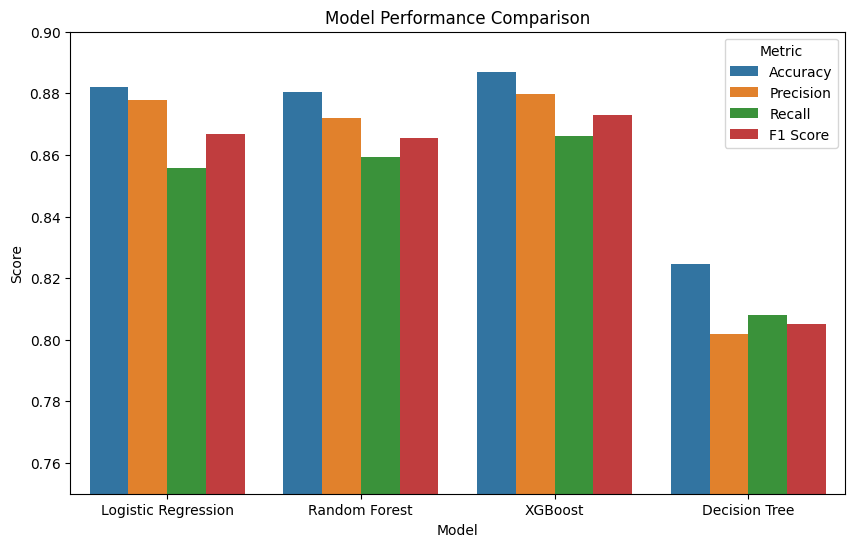

In [40]:
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison")
plt.ylim(0.75, 0.9)  # adjust if needed
plt.show()

**Model Comparison and Performance Analysis**

Multiple machine learning models were trained and evaluated, including Logistic Regression, Random Forest, XGBoost, and Decision Tree. The models were assessed using accuracy, precision, recall, and F1-score to ensure a comprehensive evaluation of performance.

Among all models, **XGBoost achieved the best overall performance**, with the highest accuracy, precision, recall, and F1-score. This indicates that XGBoost is the most effective model for predicting heart disease in this dataset, as it is able to capture complex relationships between features and handle nonlinear patterns efficiently.

Logistic Regression performed competitively and provided a strong baseline model, demonstrating good performance across all metrics. However, its linear nature limits its ability to capture more complex feature interactions compared to ensemble methods.

Random Forest also delivered strong results, performing slightly below XGBoost but still maintaining high accuracy and balanced precision and recall. Its ensemble structure helps reduce overfitting and improves generalization.

On the other hand, the Decision Tree model showed comparatively lower performance, particularly in terms of precision, recall, and F1-score. This is likely due to overfitting and its inability to generalize well compared to ensemble-based methods.

Overall, ensemble models such as **Random Forest and XGBoost** outperform simpler models, with XGBoost emerging as the best-performing model. Additionally, recall is particularly important in this problem, as it reflects the model's ability to correctly identify patients with heart disease. XGBoost achieves the highest recall, making it especially suitable for medical applications where minimizing false negatives is critical.

**Cross-validation**

Cross-validation was performed to evaluate the model's stability and generalization ability.

Random Forest (bagging) and XGBoost (boosting) were used to improve model performance by combining multiple decision trees. These ensemble methods help reduce overfitting and improve generalization.

In [41]:
# Cross-validation
model = XGBClassifier(eval_metric='logloss')

scores = cross_val_score(model, X, y, cv=5, scoring='f1')

print("Cross-validation scores:", scores)
print("Mean F1-score:", scores.mean())

Cross-validation scores: [0.87499554 0.87268475 0.87504796 0.8735774  0.8748272 ]
Mean F1-score: 0.8742265689456248


Cross-Validation Results

Cross-validation was performed using 5-fold validation to assess the stability and generalization capability of the model. The model achieved an average F1-score of approximately 0.87, with very minimal variation across different folds.

The consistency of the scores indicates that the model is stable and does not suffer from overfitting. This demonstrates that the model generalizes well to unseen data and maintains reliable performance across different subsets of the dataset.

Overall, the cross-validation results confirm that the selected model is robust and suitable for predicting heart disease.

In [42]:
final_model =  XGBClassifier(eval_metric='logloss', random_state=42)

final_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [43]:
# pickle

with open("heart_disease_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

Model Saving:

After training the final model on the entire dataset, the model was saved using the pickle library. This allows the trained model to be reused without retraining and enables deployment in real-world applications.

**Submission**

In [44]:
test_df.head(1)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3


In [45]:
test_ids = test_df["id"]
test_df = test_df.drop("id", axis=1)

In [46]:
pred_proba = final_model.predict_proba(test_df)[:, 1]

In [47]:
submission = pd.DataFrame({
    "id": test_ids,
    "Heart Disease": pred_proba
})

submission.to_csv("submission.csv", index=False)

**Manual Testing**

In [48]:
# manual testing
manual_input = {
    "Age": [55],
    "Sex": [1],
    "Chest pain type": [4],
    "BP": [140],
    "Cholesterol": [250],
    "FBS over 120": [0],
    "EKG results": [2],
    "Max HR": [150],
    "Exercise angina": [1],
    "ST depression": [2.3],
    "Slope of ST": [2],
    "Number of vessels fluro": [1],
    "Thallium": [7]
}

manual_input_df = pd.DataFrame(manual_input)

# Ensure correct column order
manual_input_df = manual_input_df[X.columns]

# Predict
prediction = xgb.predict(manual_input_df)[0]
probability = xgb.predict_proba(manual_input_df)[0][1]

if prediction == 1:
    print(f"Heart Disease: Presence (Probability: {probability:.2f})")
else:
    print(f"Heart Disease: Absence (Probability: {1 - probability:.2f})")

Heart Disease: Presence (Probability: 0.99)


In [49]:
manual_input = {
    "Age": [35],
    "Sex": [0],
    "Chest pain type": [3],
    "BP": [120],
    "Cholesterol": [200],
    "FBS over 120": [0],
    "EKG results": [0],
    "Max HR": [170],
    "Exercise angina": [0],
    "ST depression": [0.0],
    "Slope of ST": [1],
    "Number of vessels fluro": [0],
    "Thallium": [3]
}


manual_input_df = pd.DataFrame(manual_input)

# Ensure correct column order
manual_input_df = manual_input_df[X.columns]

# Predict
prediction = xgb.predict(manual_input_df)[0]
probability = xgb.predict_proba(manual_input_df)[0][1]

if prediction == 1:
    print(f"Heart Disease: Presence (Probability: {probability:.2f})")
else:
    print(f"Heart Disease: Absence (Probability: {1 - probability:.2f})")

Heart Disease: Absence (Probability: 1.00)
